In [11]:
from google.colab import files
uploaded = files.upload()  # selecciona excel_lab_RLC.xlsx desde tu computador

df = pd.read_excel("excel_lab_RLC.xlsx", sheet_name="Hoja1", header=None)

Saving excel_lab_RLC.xlsx to excel_lab_RLC (1).xlsx


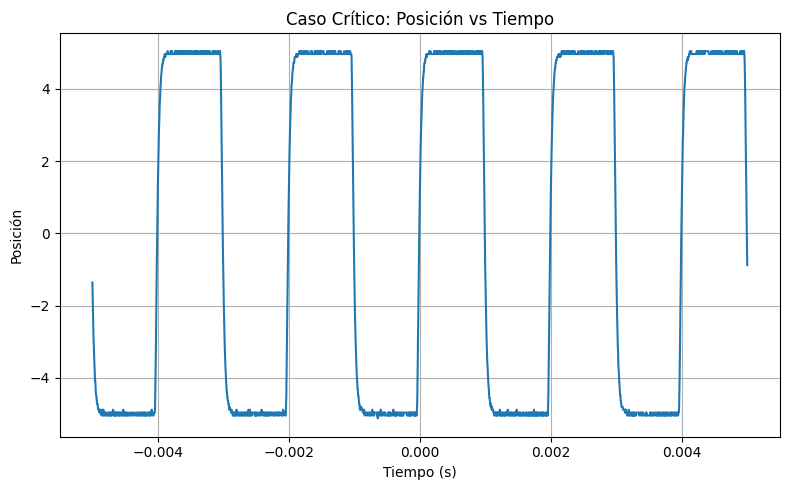

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_excel("excel_lab_RLC.xlsx", sheet_name="Hoja1", header=None)

# Columnas E (índice 4) y F (índice 5)
tiempo_critico = df.iloc[1:, 4].astype(float)
posicion_critico = df.iloc[1:, 5].astype(float)

plt.figure(figsize=(8, 5))
plt.plot(tiempo_critico, posicion_critico, color="tab:blue")
plt.title("Caso Crítico: Posición vs Tiempo")
plt.xlabel("Tiempo (s)")
plt.ylabel("Posición")
plt.grid(True)
plt.tight_layout()
plt.show()

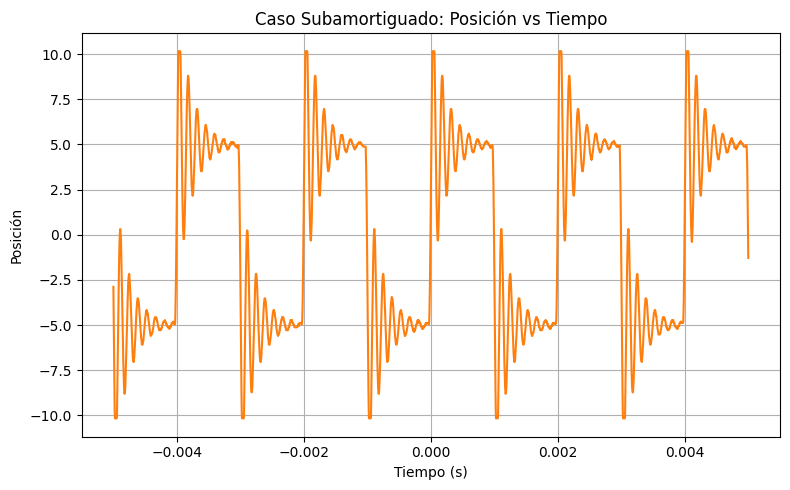

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_excel("excel_lab_RLC.xlsx", sheet_name="Hoja1", header=None)

# Columnas L (índice 11) y M (índice 12)
tiempo_sub = df.iloc[1:, 11].astype(float)
posicion_sub = df.iloc[1:, 12].astype(float)

plt.figure(figsize=(8, 5))
plt.plot(tiempo_sub, posicion_sub, color="tab:orange")
plt.title("Caso Subamortiguado: Posición vs Tiempo")
plt.xlabel("Tiempo (s)")
plt.ylabel("Posición")
plt.grid(True)
plt.tight_layout()
plt.show()

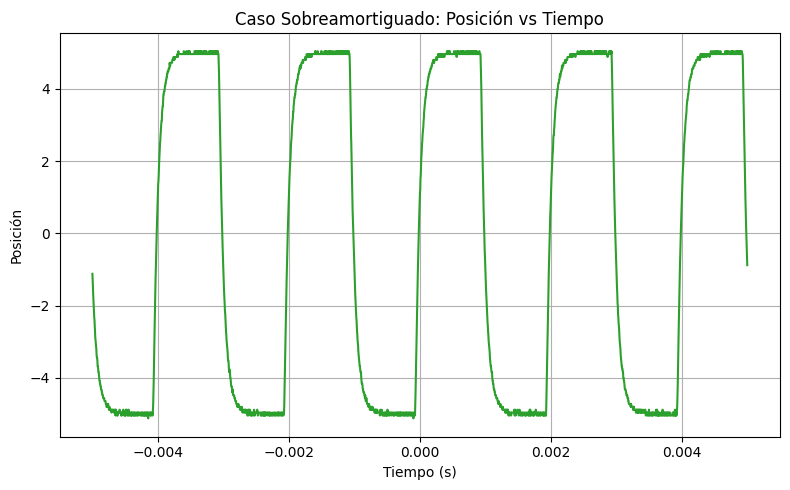

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_excel("excel_lab_RLC.xlsx", sheet_name="Hoja1", header=None)

# Columnas S (índice 18) y T (índice 19)
tiempo_sobre = df.iloc[1:, 18].astype(float)
posicion_sobre = df.iloc[1:, 19].astype(float)

plt.figure(figsize=(8, 5))
plt.plot(tiempo_sobre, posicion_sobre, color="tab:green")
plt.title("Caso Sobreamortiguado: Posición vs Tiempo")
plt.xlabel("Tiempo (s)")
plt.ylabel("Posición")
plt.grid(True)
plt.tight_layout()
plt.show()

A     = 7.4271
gamma = 4153.73 1/s   (tau = 0.2407 ms)
omega = 44975.55 rad/s (f = 7158.08 Hz)
phi   = 4.6653 rad
C     = 4.8773
R^2   = 0.9007


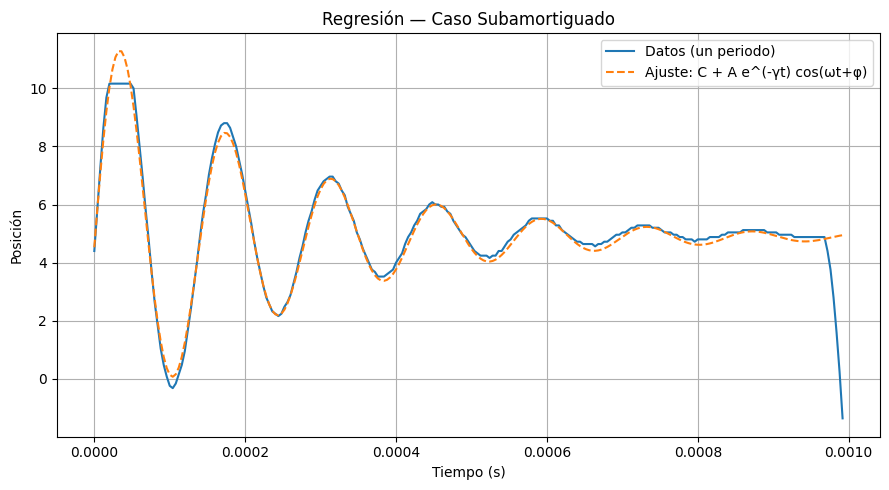

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

df = pd.read_excel("excel_lab_RLC.xlsx", sheet_name="Hoja1", header=None)

t_full = df.iloc[1:, 11].astype(float).values
y_full = df.iloc[1:, 12].astype(float).values

# La señal es periódica (tren de oscilaciones amortiguadas cada 1 ms).
# Aislamos un solo periodo/decaimiento para hacer la regresión física.
mask = (t_full >= -0.002) & (t_full < -0.001)
ts = t_full[mask]
ys = y_full[mask]

# Quitamos el/los primeros puntos si están saturados (clipping del osciloscopio)
k = 0
while k < len(ys) - 1 and ys[k] == ys[0]:
    k += 1
ts, ys = ts[k:], ys[k:]

t0 = ts[0]
tt = ts - t0  # tiempo relativo al inicio del segmento

# Modelo físico de oscilador subamortiguado:
# x(t) = C + A * exp(-gamma*t) * cos(omega*t + phi)
def oscilador_sub(t, A, gamma, omega, phi, C):
    return C + A * np.exp(-gamma * t) * np.cos(omega * t + phi)

# Estimaciones iniciales (frecuencia via FFT, resto por inspección)
dt = t_full[1] - t_full[0]
C0 = ys[-30:].mean()
A0 = ys[0] - C0
espectro = np.fft.rfft(ys - np.mean(ys))
frecs = np.fft.rfftfreq(len(ys), dt)
f0 = frecs[np.argmax(np.abs(espectro[1:])) + 1]
p0 = [A0, 1500, 2*np.pi*f0, 0, C0]

popt, pcov = curve_fit(oscilador_sub, tt, ys, p0=p0, maxfev=50000)
A, gamma, omega, phi, C = popt
f = omega / (2*np.pi)

# R^2
residuos = ys - oscilador_sub(tt, *popt)
r2 = 1 - np.sum(residuos**2) / np.sum((ys - np.mean(ys))**2)

print(f"A     = {A:.4f}")
print(f"gamma = {gamma:.2f} 1/s   (tau = {1/gamma*1000:.4f} ms)")
print(f"omega = {omega:.2f} rad/s (f = {f:.2f} Hz)")
print(f"phi   = {phi % (2*np.pi):.4f} rad")
print(f"C     = {C:.4f}")
print(f"R^2   = {r2:.4f}")

plt.figure(figsize=(9, 5))
plt.plot(tt, ys, label="Datos (un periodo)")
plt.plot(tt, oscilador_sub(tt, *popt), "--", label="Ajuste: C + A e^(-γt) cos(ωt+φ)")
plt.title("Regresión — Caso Subamortiguado")
plt.xlabel("Tiempo (s)")
plt.ylabel("Posición")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()